# Data Preprocessing

## Download & export data tables

### Download Microsoft OHLCV with `yfinance` library

**Search for the ticker code**

YFinance: https://finance.yahoo.com/

- [ ] Microsoft: ???

In [2]:
import yfinance as yf


/Users/neemaurassa/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [3]:
ticker = 'MSFT'
df_MSFT= yf.download(tickers=ticker)

[*********************100%***********************]  1 of 1 completed


### Download any ticker

- [x] Microsoft: MSFT
- [ ] Bitcoin: ???

In [4]:
ticker = 'BTC-USD'
df_BTC = yf.download(ticker, multi_level_index=False, auto_adjust=False)
df_BTC

[*********************100%***********************]  1 of 1 completed


,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2026-04-27,77366.625000,77366.625000,79488.171875,76481.343750,78661.015625,38135631927
2026-04-28,76350.671875,76350.671875,77483.867188,75673.601562,77368.117188,32056900880
2026-04-29,75776.132812,75776.132812,77884.968750,74958.570312,76350.687500,41460907886
2026-04-30,76304.320312,76304.320312,76611.484375,75318.984375,75778.632812,29497862305
2026-05-01,78179.000000,78179.000000,78894.976562,76294.695312,76305.054688,39164328894
2026-05-02,78657.250000,78657.250000,79119.789062,78031.960938,78177.750000,16761531851
2026-05-03,78538.226562,78538.226562,79402.359375,78073.078125,78656.726562,20544392639
2026-05-04,79827.906250,79827.906250,80742.359375,78217.960938,78540.289062,54325085296
2026-05-05,80927.054688,80927.054688,81751.453125,79787.578125,79823.531250,39700107376


## Visualize the data with plotly

https://plotly.com/python/candlestick-charts/

In [5]:
df_MSFT

Price,Close,High,Low,Open,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT
Date,,,,,
2026-04-27,423.901886,426.186915,416.168635,421.467157,30867300
2026-04-28,428.322296,428.990862,420.988175,423.652418,30438100
2026-04-29,423.542633,425.897548,419.381662,423.662369,38288300
2026-04-30,406.898712,413.524377,397.149838,409.922163,70909400
2026-05-01,413.544312,416.208524,409.552956,411.907841,31372400
2026-05-04,412.726074,419.870604,409.912162,410.650583,28066500
2026-05-05,410.490936,415.879260,407.916495,414.422424,25700900
2026-05-06,413.065338,417.515721,404.234459,407.118227,30285900


In [6]:

import plotly.graph_objects as go
df= df_MSFT
df_MSFT = yf.download('MSFT', start='2016-12-08', end='2026-05-22',
                       multi_level_index=False, auto_adjust=False)
fig = go.Figure(data=[go.Candlestick(x=df.index,
                open=df['Open'],
                high=df['High'],
                low=df['Low'],
                close=df['Close'])])

fig.show()

[*********************100%***********************]  1 of 1 completed


In [7]:
df = df_BTC

df_BTC = yf.download('BTC-USD', period='1y', interval='1d', 
                       multi_level_index=False, auto_adjust=False)
go.Figure(data=[go.Candlestick(
    x=df.index,
    open=df['Open'],
    high=df['High'],
    low=df['Low'],
    close=df['Close'])])

[*********************100%***********************]  1 of 1 completed


## Export the data

### Microsoft data

#### Drop `Adj Close`

- To not confuse the `Close` and `Adj Close`

In [8]:
df_MSFT = df_MSFT.drop(columns='Adj Close')

#### To Excel

- Create a folder called `data`

#### To CSV

- Less size in memory

### Bitcoin data altogether (step by step)

#### Define ticker

In [9]:
ticker = 'BTC-USD'
ticker

'BTC-USD'

#### Download OLHVC

In [10]:
df_ticker = yf.download(ticker, multi_level_index=False, auto_adjust=False)
df_ticker

[*********************100%***********************]  1 of 1 completed


,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2026-04-27,77366.625000,77366.625000,79488.171875,76481.343750,78661.015625,38135631927
2026-04-28,76350.671875,76350.671875,77483.867188,75673.601562,77368.117188,32056900880
2026-04-29,75776.132812,75776.132812,77884.968750,74958.570312,76350.687500,41460907886
2026-04-30,76304.320312,76304.320312,76611.484375,75318.984375,75778.632812,29497862305
2026-05-01,78179.000000,78179.000000,78894.976562,76294.695312,76305.054688,39164328894
2026-05-02,78657.250000,78657.250000,79119.789062,78031.960938,78177.750000,16761531851
2026-05-03,78538.226562,78538.226562,79402.359375,78073.078125,78656.726562,20544392639
2026-05-04,79827.906250,79827.906250,80742.359375,78217.960938,78540.289062,54325085296
2026-05-05,80927.054688,80927.054688,81751.453125,79787.578125,79823.531250,39700107376


#### Create file path

In [11]:
file_path = f'data/{ticker}.xlsx'
file_path

'data/BTC-USD.xlsx'

#### Export to Excel

In [12]:
!pip install openpyxl


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [13]:
import sys
!{sys.executable} -m pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [14]:
df_ticker.to_excel(file_path)

#### Export to CSV

In [15]:
df_ticker.to_csv(f'data/{ticker}.csv')

#### Snippet

In [16]:
ticker = 'NVDA'
df_ticker = yf.download(ticker, multi_level_index=False, auto_adjust=False)
df_ticker.to_excel(f'data/{ticker}.xlsx')
df_ticker.to_csv(f'data/{ticker}.csv')

[*********************100%***********************]  1 of 1 completed


## [ ] Data Preprocessing

In [17]:
???

Object `?` not found.


### Load the data

In [18]:
import pandas as pd

df_microsoft = pd.read_excel(
    'data/Microsoft_Stock_Price_Historical_Daily.xlsx',
    parse_dates=['Date'], index_col=0
)

df_microsoft

,Open,High,Low,Close,Volume
Date,,,,,
1986-03-13,0.088542,0.101563,0.088542,0.097222,1031788800
1986-03-14,0.097222,0.102431,0.097222,0.100694,308160000
1986-03-17,0.100694,0.103299,0.100694,0.102431,133171200
1986-03-18,0.102431,0.103299,0.098958,0.099826,67766400
1986-03-19,0.099826,0.100694,0.097222,0.098090,47894400
...,...,...,...,...,...
2023-05-22,318.600006,322.589996,318.010010,321.179993,24115700
2023-05-23,320.029999,322.720001,315.250000,315.260010,30797200
2023-05-24,314.730011,316.500000,312.609985,313.850006,23384900


### Filter the data

![](src/Microsoft_x_LinkedIn.png)

In [19]:
df_MSFT_linkedin= df_MSFT.loc['2016-12-08':,:].copy()

## Create new columns

### Tomorrow's percentage change

In [20]:
df_MSFT_linkedin['change_tomorrow']=df_MSFT_linkedin.Close.pct_change(-1)*100*-1

In [21]:
df_MSFT_linkedin= df_MSFT_linkedin.dropna().copy()

### Did the stock go up or down?

In [22]:
import numpy as np

In [23]:
df_MSFT_linkedin['change_tomorrow_direction']= np.where(df_MSFT_linkedin.change_tomorrow > 0, 'UP', 'DOWN')

In [24]:
df_MSFT_linkedin.change_tomorrow_direction.value_counts()

change_tomorrow_direction
UP      1269
DOWN    1105
Name: count, dtype: int64

In [25]:
import sys
!{sys.executable} -m pip install matplotlib 

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


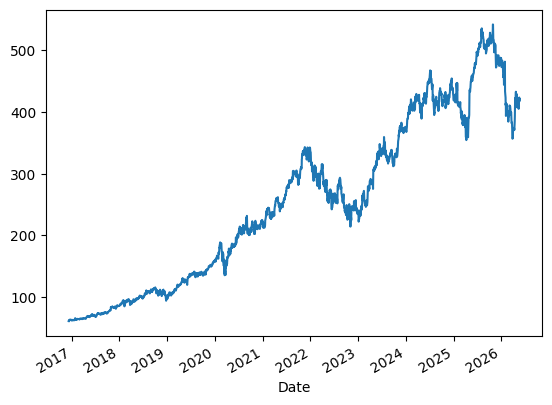

In [26]:
df_MSFT_linkedin.Close.plot();

## Export preprocessed DataFrame into an Excel

In [27]:
df_MSFT_linkedin.to_excel('data/microsoft_linkedin_Processed.xlsx')